# **Random Forest Baseline Models: 9 Skin Lesion Classes**

This notebook builds and evaluates two baseline Random Forest classifiers for a 9-class skin lesion classification task. The first model uses the original dataset with hair artifacts, while the second model uses a version where hair has been removed. The goal is to compare whether hair removal improves baseline classification performance.


---

## **Model 1:** Random Forest Using the Dataset With Hair

This section loads the original dataset, splits it into training and testing data, trains a Random Forest classifier, and evaluates the model using class distributions, classification metrics, and a confusion matrix heatmap.


#### **Load the dataset**

The dataset is loaded into a pandas DataFrame. Displaying the first five rows helps confirm that the file loaded correctly, that the `label` column is present, and that the feature columns are formatted as expected before modeling.


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/SC_Dataset_9_Classes.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,avg_r,avg_g,avg_b,hist_feature_0,hist_feature_1,hist_feature_2,hist_feature_3,hist_feature_4,hist_feature_5,hist_feature_6,...,sobel_r,sobel_g,sobel_b,min_enc_circle_radius,min_enc_circle_area,min_area_rect_width,min_area_rect_height,min_area_rect_aspect_ratio,min_area_rect_angle,label
0,215.435722,154.768741,160.486663,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,16.298068,15.719409,23.341190,374.300110,4.401389e+05,449.0,599.0,0.749583,-90.0,vascular lesion
1,203.781219,179.247785,208.150415,0.0,0.0,0.0,0.0,1.0,2.0,4.0,...,14.113285,14.688772,13.842412,374.300110,4.401389e+05,449.0,599.0,0.749583,-90.0,vascular lesion
2,195.706115,120.804822,142.253215,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.913575,18.003877,23.534902,374.300110,4.401389e+05,449.0,599.0,0.749583,-90.0,vascular lesion
3,144.887641,136.410988,136.469449,32976.0,19025.0,7816.0,15109.0,10365.0,7888.0,8398.0,...,11.781067,12.010911,13.011458,638.200134,1.279569e+06,766.0,1021.0,0.750245,-90.0,nevus
4,134.110788,147.433253,167.797929,5904.0,5218.0,1957.0,1837.0,2940.0,5767.0,8627.0,...,16.715419,16.783175,19.196752,638.200134,1.279569e+06,766.0,1021.0,0.750245,-90.0,nevus


### **Separate features and labels, then create the train/test split**

The label column is stored as the target variable y, while all remaining columns are used as input features X. The notebook uses the first 119 rows as the test set and the remaining rows as the training set. Printing the shapes verifies that the split produced matching feature and label dimensions.


In [ ]:
X = df.drop('label', axis=1)
y = df['label']

# Split X into training and testing sets
X_test = X[:119]
X_train = X[119:]

# Split y into training and testing sets
y_test = y[:119]
y_train = y[119:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2238, 130)
X_test shape: (119, 130)
y_train shape: (2238,)
y_test shape: (119,)


### **Check the class distribution in the test set**

Before interpreting model performance, it is important to check how many examples of each class are in the test set. Class imbalance can make accuracy misleading, because a model may appear to perform well overall while failing on smaller or more difficult classes.


In [ ]:
print('Class occurrences in y_test:')
print(y_test.value_counts())

Class occurrences in y_test:
label
nevus                         16
pigmented benign keratosis    16
squamous cell carcinoma       16
dermatofibroma                16
melanoma                      16
actinic keratosis             16
basal cell carcinoma          16
vascular lesion                4
seborrheic keratosis           3
Name: count, dtype: int64


### **Test set class distribution**

This bar chart shows the number of test images in each class. It helps identify whether the evaluation set is balanced and whether some classes have very low support. Classes with fewer test examples, such as seborrheic keratosis and vascular lesion in this section, may have less stable performance metrics.


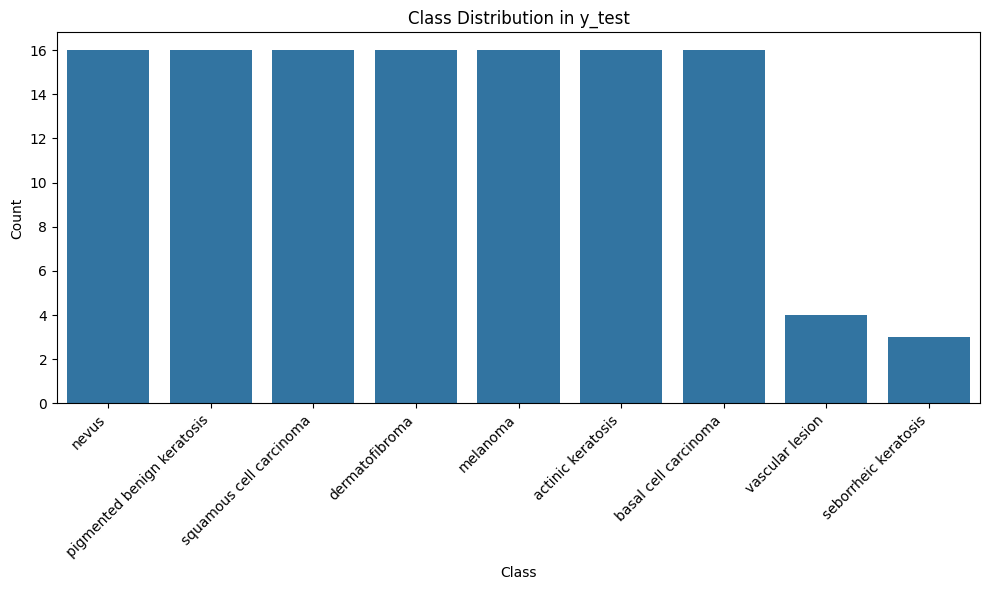

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts of y_test
y_test_counts = y_test.value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=y_test_counts.index, y=y_test_counts.values)

# Set the title and labels
plt.title('Class Distribution in y_test')
plt.xlabel('Class')
plt.ylabel('Count')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Ensure tight layout
plt.tight_layout()

# Display the plot
plt.show()

### **Train the baseline Random Forest model**

A RandomForestClassifier is trained using the training features and labels. The random_state=42 argument makes the model results reproducible. Since this is a baseline model, no hyperparameter tuning is applied yet.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


### **Generate predictions on the test set**

After training, the model predicts labels for the held-out test set. These predictions are later compared with the true labels to measure model performance.


In [ ]:
y_pred = rf_model.predict(X_test)

### **Evaluate the model with precision, recall, F1-score, accuracy, and a confusion matrix**

The classification report gives class-by-class metrics. Precision measures how often predicted examples of a class are correct, recall measures how many true examples of that class are found, and F1-score balances precision and recall. The confusion matrix shows exactly which classes are being confused with one another.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.40      0.62      0.49        16
            dermatofibroma       1.00      0.19      0.32        16
                  melanoma       0.11      0.12      0.12        16
                     nevus       0.32      0.88      0.47        16
pigmented benign keratosis       0.48      0.62      0.54        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.25      0.06      0.10        16
           vascular lesion       0.75      0.75      0.75         4

                  accuracy                           0.36       119
                 macro avg       0.37      0.36      0.31       119
              weighted avg       0.37      0.36      0.30       119

Confusion Matrix:
[[ 0  0  0  0 15  1  0  0  0]
 [ 0 10  0  0  0  5  0  1  0]
 [ 0  3  3  

## **Model 1 Summary: Dataset With Hair**

The Random Forest baseline using the dataset with hair performs poorly overall. The model reaches an accuracy of **0.36** on **119** test examples. The macro average F1-score is **0.31**, and the weighted average F1-score is **0.30**, showing that performance is weak across many classes.

Key findings:

- The model fails completely on **actinic keratosis** and **seborrheic keratosis**, with 0.00 precision, recall, and F1-score for both classes.
- **Nevus** has high recall at 0.88, meaning most true nevus cases are found, but it is also a common false prediction for other classes.
- **Vascular lesion** performs best in this run, with an F1-score of 0.75, though this class has only 4 test examples.
- **Melanoma** performance is very weak, with only 2 of 16 melanoma cases correctly identified. This is concerning because melanoma is one of the most important classes to detect accurately.
- The model frequently predicts difficult cases as **nevus**, suggesting the feature representation may not separate visually similar lesion types well enough.


### **Confusion matrix heatmap**

The heatmap visualizes the confusion matrix from the model using the dataset with hair. Rows represent the true class, while columns represent the predicted class. Strong diagonal values indicate correct predictions; large off-diagonal values indicate misclassifications. This plot makes it easier to see that many classes are being confused with nevus, melanoma, or pigmented benign keratosis.


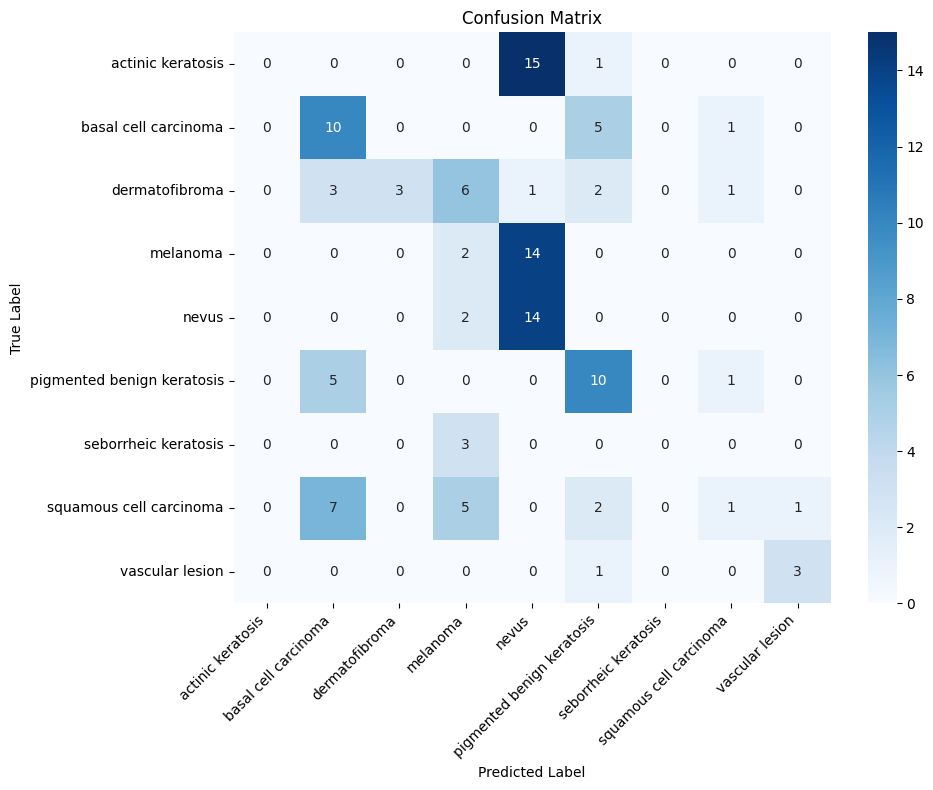

In [ ]:
import numpy as np

# 1. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Obtain unique class labels from y_test
class_labels = np.unique(y_test).tolist()

# 3. Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

# 4. Add a title to the plot
plt.title('Confusion Matrix')

# 5. Label the x-axis as 'Predicted Label' and the y-axis as 'True Label'
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 6. Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 7. Ensure tight layout
plt.tight_layout()

# 8. Display the plot
plt.show()

### **Confusion Matrix Comments**

The confusion matrix confirms that the model struggles to distinguish several lesion classes. All 16 actinic keratosis examples are misclassified, mostly as nevus. Melanoma is also often confused with nevus: 14 of 16 melanoma examples are predicted as nevus. Dermatofibroma and squamous cell carcinoma also show weak recall, meaning the model misses most true examples from these classes. The strongest diagonal counts appear for nevus, basal cell carcinoma, pigmented benign keratosis, and vascular lesion, but even these classes still show important errors.


---

# **Model 2:** Random Forest Using the Dataset Without Hair

This section repeats the same baseline modeling process using the hair-removed version of the dataset. The purpose is to test whether removing hair artifacts improves classification performance.


### Step 7: Load the hair-removed dataset

The no-hair dataset is loaded into a separate DataFrame. Displaying the first five rows confirms that the file loaded correctly and has the same basic structure as the original dataset.


In [ ]:
import pandas as pd

# Load the dataset without hair
df_no_hair = pd.read_csv('/content/SC_Dataset_9_Classes_No_Hair.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset without hair:')
display(df_no_hair.head())

First 5 rows of the dataset without hair:


,avg_r,avg_g,avg_b,hist_feature_0,hist_feature_1,hist_feature_2,hist_feature_3,hist_feature_4,hist_feature_5,hist_feature_6,...,sobel_r,sobel_g,sobel_b,min_enc_circle_radius,min_enc_circle_area,min_area_rect_width,min_area_rect_height,min_area_rect_aspect_ratio,min_area_rect_angle,label
0,194.712719,114.467541,118.001681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.246133,14.887271,15.286135,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion
1,175.535274,136.536304,148.196396,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.538361,16.201347,16.145047,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion
2,190.775719,122.270748,131.896830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.315433,20.137459,19.725680,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion
3,180.752363,123.156296,140.377622,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.397946,17.291009,18.002254,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion
4,230.938519,147.229526,158.869841,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.677937,13.512262,14.119405,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion


### **Separate features and labels, then create the no-hair train/test split**

The no-hair dataset is split into features and labels using the same approach as the first model. The first 142 rows are used as the test set, and the remaining rows are used for training. Shape checks verify that the feature and label arrays match.


In [ ]:
X_no_hair = df_no_hair.drop('label', axis=1)
y_no_hair = df_no_hair['label']

X_test_no_hair = X_no_hair[:142]
X_train_no_hair = X_no_hair[142:]

y_test_no_hair = y_no_hair[:142]
y_train_no_hair = y_no_hair[142:]

print(f"X_train_no_hair shape: {X_train_no_hair.shape}")
print(f"X_test_no_hair shape: {X_test_no_hair.shape}")
print(f"y_train_no_hair shape: {y_train_no_hair.shape}")
print(f"y_test_no_hair shape: {y_test_no_hair.shape}")

X_train_no_hair shape: (2215, 130)
X_test_no_hair shape: (142, 130)
y_train_no_hair shape: (2215,)
y_test_no_hair shape: (142,)


### **No-hair test set class distribution**

This bar chart shows the class distribution for the no-hair test set. Compared with the first test set, this version has more test examples overall and more vascular lesion and seborrheic keratosis examples. This matters because performance comparisons between the two models are affected by differences in test set size and class support.


Class occurrences in y_test_no_hair:
label
vascular lesion               17
nevus                         16
squamous cell carcinoma       16
dermatofibroma                16
melanoma                      16
pigmented benign keratosis    16
basal cell carcinoma          16
actinic keratosis             16
seborrheic keratosis          13
Name: count, dtype: int64


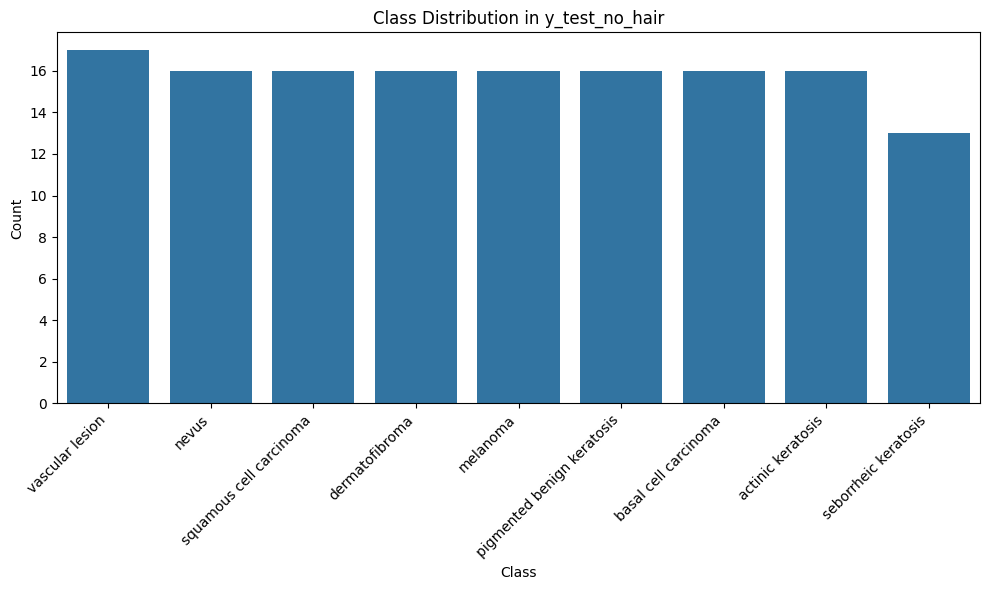

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts of y_test_no_hair
y_test_no_hair_counts = y_test_no_hair.value_counts()

print('Class occurrences in y_test_no_hair:')
print(y_test_no_hair_counts)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=y_test_no_hair_counts.index, y=y_test_no_hair_counts.values)

# Set the title and labels
plt.title('Class Distribution in y_test_no_hair')
plt.xlabel('Class')
plt.ylabel('Count')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Ensure tight layout
plt.tight_layout()

# Display the plot
plt.show()

### **Train the no-hair Random Forest model**

A second RandomForestClassifier is trained on the no-hair training data. Keeping the same model type and random state allows the comparison to focus mainly on the dataset difference rather than a change in modeling method.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier model for 'no hair' data
rf_model_no_hair = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model_no_hair.fit(X_train_no_hair, y_train_no_hair)

print("RandomForestClassifier model for 'no hair' data trained successfully.")

RandomForestClassifier model for 'no hair' data trained successfully.


### **Generate predictions for the no-hair test set**

The trained no-hair model predicts labels for the no-hair test set. These predictions are then evaluated against the true no-hair test labels.


In [ ]:
y_pred_no_hair = rf_model_no_hair.predict(X_test_no_hair)

### **Evaluate the no-hair model**

The same metrics are used for the no-hair model: classification report, accuracy, class-level precision/recall/F1-score, and confusion matrix. Using the same evaluation process makes the two baseline models easier to compare.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate and print the classification report
print("Classification Report (No Hair Data):")
print(classification_report(y_test_no_hair, y_pred_no_hair, zero_division=0))

# Generate and print the confusion matrix
print("Confusion Matrix (No Hair Data):")
print(confusion_matrix(y_test_no_hair, y_pred_no_hair))

Classification Report (No Hair Data):
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.31      0.50      0.38        16
            dermatofibroma       1.00      0.19      0.32        16
                  melanoma       0.12      0.25      0.16        16
                     nevus       0.26      0.62      0.37        16
pigmented benign keratosis       0.36      0.56      0.44        16
      seborrheic keratosis       0.00      0.00      0.00        13
   squamous cell carcinoma       0.43      0.19      0.26        16
           vascular lesion       1.00      0.53      0.69        17

                  accuracy                           0.32       142
                 macro avg       0.39      0.32      0.29       142
              weighted avg       0.40      0.32      0.30       142

Confusion Matrix (No Hair Data):
[[ 0  0  0  0 15  1  0  0  0]
 [ 0  8  0  

## **Model 2 Summary: Dataset Without Hair**

The Random Forest baseline using the no-hair dataset also performs poorly overall. The model reaches an accuracy of **0.32** on **142** test examples. The macro average F1-score is **0.29**, and the weighted average F1-score is **0.30**.

Key findings:

- Removing hair does **not** improve overall accuracy in this baseline run; accuracy decreases from 0.36 to 0.32.
- **Melanoma recall improves** from 0.12 to 0.25, meaning the no-hair model correctly identifies 4 of 16 melanoma cases instead of 2 of 16. However, many melanoma cases are still confused with nevus.
- **Actinic keratosis** and **seborrheic keratosis** still have 0.00 precision, recall, and F1-score, meaning the model does not correctly identify either class.
- **Vascular lesion** remains one of the stronger classes, with an F1-score of 0.69, but the model still misses 8 of 17 true vascular lesion examples.
- The no-hair model still shows heavy confusion among melanoma, nevus, basal cell carcinoma, and pigmented benign keratosis.


### **No-hair confusion matrix heatmap**

This heatmap shows the confusion matrix for the model trained on the no-hair dataset. The plot is used to identify whether hair removal changes the model’s error patterns. Ideally, hair removal would increase the diagonal values and reduce off-diagonal confusion, especially for clinically important classes such as melanoma.


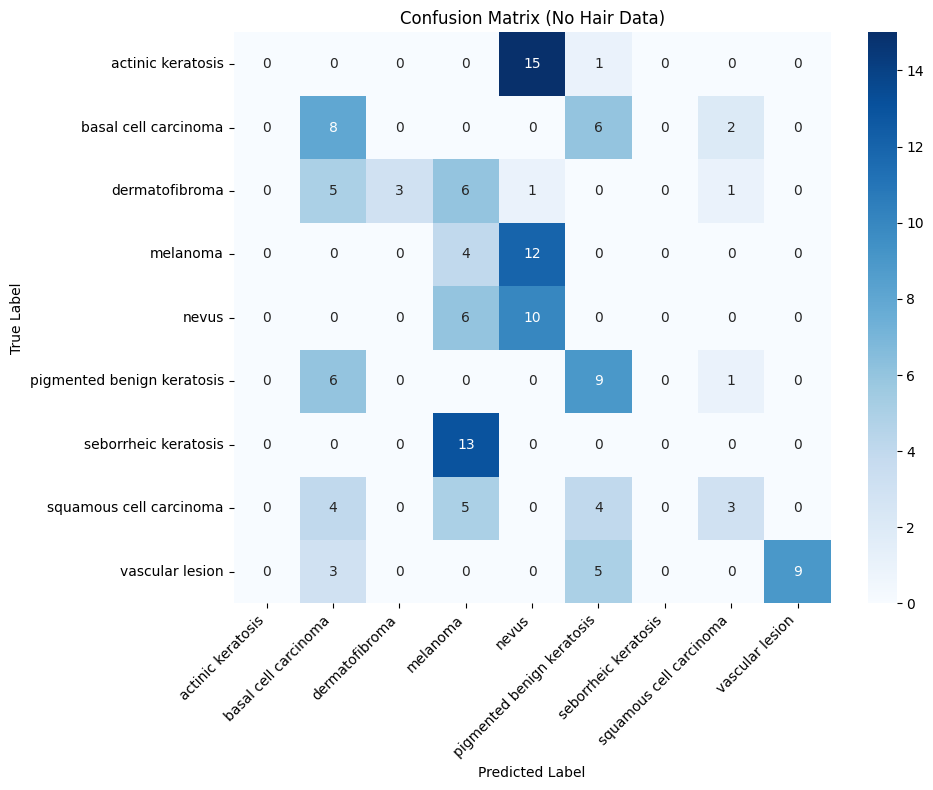

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate the confusion matrix
cm_no_hair = confusion_matrix(y_test_no_hair, y_pred_no_hair)

# 2. Obtain unique class labels from y_test_no_hair
class_labels_no_hair = np.unique(y_test_no_hair).tolist()

# 3. Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_no_hair, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_no_hair, yticklabels=class_labels_no_hair)

# 4. Add a title to the plot
plt.title('Confusion Matrix (No Hair Data)')

# 5. Label the x-axis as 'Predicted Label' and the y-axis as 'True Label'
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 6. Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 7. Ensure tight layout
plt.tight_layout()

# 8. Display the plot
plt.show()

### **Confusion Matrix Comments**

The no-hair confusion matrix shows that the model still has major classification problems. All actinic keratosis cases are misclassified, mostly as nevus. All seborrheic keratosis cases are misclassified as melanoma. Melanoma improves slightly compared with the with-hair model, but 12 of 16 melanoma cases are still predicted as nevus. Nevus is also confused with melanoma, showing that the model has difficulty separating these two visually similar categories.


---

## Overall Comparison and Next Steps

Across both baseline models, Random Forest performance is not strong enough for reliable 9-class skin lesion classification. The with-hair model has slightly higher overall accuracy, while the no-hair model shows a small improvement in melanoma recall. However, both models fail on multiple classes and show repeated confusion between melanoma and nevus.

